In [19]:
import pandas as pd
#Imports Libraries

file_path = "Alan-pulley-3points"
file = open(file_path + ".txt", "r")
lines = file.readlines()
#Read everything in the data file into lines
#lines is a list, each element is one line in the data file


i = 0
while lines[i] != "4) Trace Data\n":
    i += 1
i += 2
#Finds where the raw data starts
#Skips the two blank lines at very beginging


raw_data = []
for j in range(i, len(lines)):
    line = lines[j]
    bloodflow_val = float(line.split("\t")[4])
    raw_data.append(bloodflow_val)
#Example of line: 720  0   11   59   21.8     0.0
#Extacts the blood perfusion(Which is value on index 4), in this case 21.8
#Appends all blood perfusion into raw_data list


points = ["outergate", "hand3mile", "hand5mile"]
activities = ["baseline", "0lbs", "5lbs", "10lbs"]
#Define Variables used in this experiment

times = pd.DataFrame(index = ["baseline", "0lbs", "5lbs", "10lbs"],
                    columns = ["outergate", "hand3mile", "hand5mile"])
times['outergate']['baseline'] = (0, 60)
times['outergate']['0lbs'] = (61, 121)
times['outergate']['5lbs'] = (122, 182)
times['outergate']['10lbs'] = (183, 243)
times['hand3mile']['baseline'] = (243, 303)
times['hand3mile']['0lbs'] = (304, 363)
times['hand3mile']['5lbs'] = (364, 423)
times['hand3mile']['10lbs'] = (424, 483)
times['hand5mile']['baseline'] = (484, 543)
times['hand5mile']['0lbs'] = (544, 603)
times['hand5mile']['5lbs'] = (604, 663)
times['hand5mile']['10lbs'] = (664, 723)
#Create Pandas Table(Times) to store all the time intervals
#Hard Coded because time intervals could vary from experiment to experiment due to errors
#Errors like accidently failing to stop the machine on time(in this case it happend during 243)


data = pd.DataFrame(index = ["baseline", "0lbs", "5lbs", "10lbs"],
                    columns = ["outergate", "hand3mile", "hand5mile"])
for i in points:
    for j in activities:
        slice_range = times[i][j]
        data[i][j] = raw_data[slice_range[0] : slice_range[1]]
#Create Pandas Table(data) to store all data
#Slice the Corresponding intervals from raw_data based on values from Times table
#Store all the data as arrays into corresponding cells




/tmp/ipython-input-186991312.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  times['outergate']['baseline'] = (0, 60)
/tmp/ipython-input-186991312.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You ar

In [5]:
import numpy as np
from sklearn.cluster import KMeans

# 1) Flatten series into 1 list of vectors
# Each vector will represent one (activity x point) combo

feature_rows = []
labels = []

for point in points:
  for activity in activities:
    values = data[point][activity]
    if isinstance(values, list) or isinstance(values, np.ndarray):
      values = pd.Series(values)
      # 2) compute summary statistics for clustering
      features = {
          "point": point,
          "activity": activity,
          "mean": values.mean(),
          "std": values.std(),
          "max": values.max(),
          "min": values.min(),
          "median": values.median(),
          "skew": values.skew(),
          "kurt": values.kurt()
      }
      feature_rows.append(features)
      labels.append(f"{point}_{activity}")

"""

# 4) standardize before k-means clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

#5) apply k-means clustering
kmeans = KMeans(n_clusters=3,random_state=42)
feature_df['Cluster'] = kmeans.fit_predict(scaled_features)

# 6) view results
print(feature_df[['activity', 'Cluster']])
"""

"\n\n# 4) standardize before k-means clustering\nscaler = StandardScaler()\nscaled_features = scaler.fit_transform(numeric_features)\n\n#5) apply k-means clustering\nkmeans = KMeans(n_clusters=3,random_state=42)\nfeature_df['Cluster'] = kmeans.fit_predict(scaled_features)\n\n# 6) view results\nprint(feature_df[['activity', 'Cluster']])\n"

In [6]:
# 3) create numeric feature DF
feature_df = pd.DataFrame(feature_rows).set_index('point')
numeric_features = feature_df [['mean', 'std', 'max', 'min', 'median', 'skew', 'kurt']]

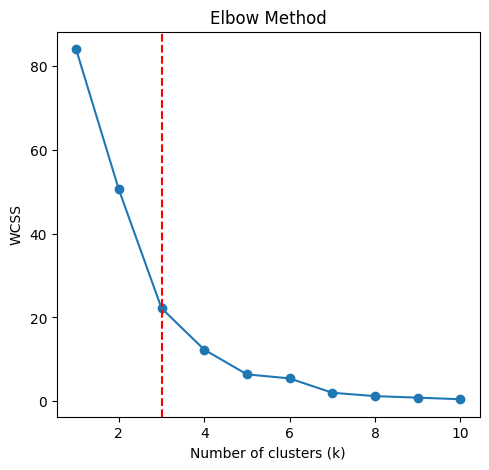

In [13]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# 4) scale everything (important for kmeans)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

wcss = []
silhouette_scores = []
max_clusters = 10

#calculate silhouette scores
for k in range(1, max_clusters +1):
  kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
  kmeans.fit(scaled_features)
  wcss.append(kmeans.inertia_)

  #can only calculate silhouette score if 1 < k < n_samples
  if 1 < k < len(scaled_features):
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

#plot elbow method graph
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, max_clusters+1), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.axvline(x=3, color='red', linestyle='--')

Elbow method graph shows that the optimal number of clusters to use for K-means clustering in this case is **3 clusters**


KeyError: 'point'

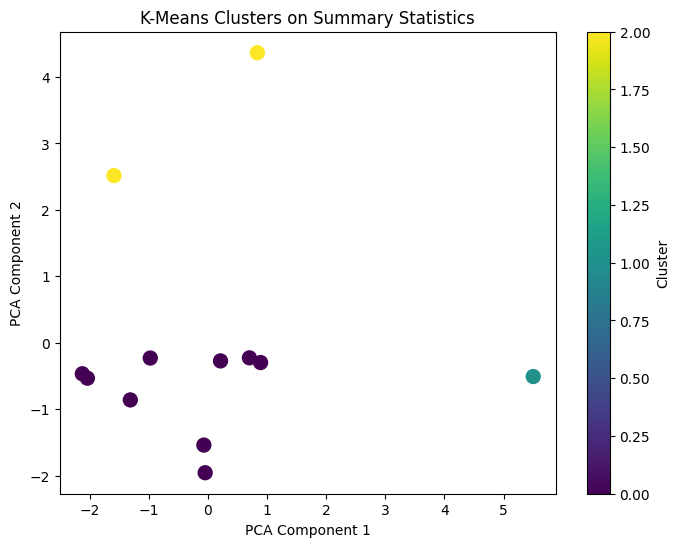

In [17]:
# Number of clusters = 3 based on elbow method
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
feature_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Step 6: Visualize clusters using 2D PCA projection for easier display
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)


plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=feature_df['Cluster'], cmap='viridis', s=100)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters on Summary Statistics')
plt.colorbar(scatter, label='Cluster')
for i, txt in enumerate(feature_df['point'] + "-" + feature_df['activity']):
    plt.annotate(txt, (pca_result[i, 0], pca_result[i, 1]), fontsize=8, alpha=0.7)
plt.tight_layout()
plt.show()

# Step 7: Print cluster assignment summary
print(feature_df[['point', 'activity', 'Cluster']])


"""# Add clustering results back to a DataFrame for easy analysis
results_df = pd.DataFrame({
    'bloodflow': raw_data,
    'cluster': labels
})

plt.figure(figsize=(12, 4))
plt.scatter(range(len(raw_data)), raw_data, c=labels, cmap='tab10', s=10)
plt.xlabel("Time (seconds or sample number)")
plt.ylabel("Bloodflow value")
plt.title("K-Means Clustering of Bloodflow Data (by sample)")
plt.colorbar(label="Cluster ID")
plt.tight_layout()
plt.show()"""

The generated k-means clusters on summary statistics showcase how data points are grouped based on feature similarities.
PCA showcases the maximum spread in the data, e.g., the axes do not represent any original measures but instead are weights indicating how much each principal component contribute for that data point.

The bottom left cluster represent the largest group of typical profiles, where bloodflow statistics are similar. Notably, their scores are low (ranging from -2 to 1) on PCA component 1 and low (all negative) on PCA component 2,
Clustering around 0 on the x-axis means this cluster's average profile is neutral/average along the main x-axis, which represents the direction of greatest variance. Clustering below 0 on the y-axis (PCA component 2) means that this cluster deviates below average along th second most important variance direction, which may represent a particular combo of original summary stats that are distinctly characterized by this value. The rough t-shape in this cluster often arises when you have a main physiological or experimental factor creating continuous variation (vertical stem), and a secondary factor or batch effect causing a split or branching (horizontal arm), which may indicate one cluster performing largely uniformly except for a subset that shifts distinctly in one feature set.


The group in the top left is characterized by less data points and a larger spread, with range from roughly (-1.5, 2.5) to (1, 5). This indicates that the data points in this cluster exhibit some variation; the domain being from -1.5 -> 1 indicates that there's moderate variation. In other words, this cluster has data points that share some core features but also have variability in those features. With a range from 2.5 to 5, the most positive in this graph, these cluster members also share strong characteristics described by the second principle component.  The wider spread on PC2 compared to PC1 means those features contributing to PC2 vary more within the cluster. Since PC1 and PC2 are weighted combinations of original summary statistics, this cluster likely groups experimental conditions with:
*  A moderate range of variation in the dominant bloodflow statistics (PC1)
*  Strong positive values in a secondary set of characteristics captured by PC2 (e.g., higher skew, or kurtosis promoting traits).